In [26]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [71]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

 Device: cpu


In [28]:
X_speech = np.load('results/X_speech.npy')
y_labels = np.load('results/y_labels.npy')
text_data = np.load('results/text_data.npy')

print(f"  Speech features shape: {X_speech.shape}")
print(f"  Labels shape: {y_labels.shape}")
print(f"  Text data shape: {text_data.shape}")

  Speech features shape: (5600, 92)
  Labels shape: (5600,)
  Text data shape: (5600,)


In [30]:
y_labels

array(['angry', 'angry', 'angry', ..., 'sad', 'sad', 'sad'],
      shape=(5600,), dtype='<U7')

In [32]:
text_data

array(['back', 'bar', 'base', ..., 'yes', 'young', 'youth'],
      shape=(5600,), dtype='<U7')

In [34]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print(f"\nEmotions: {list(label_encoder.classes_)}")
print(f"Number of classes: {len(label_encoder.classes_)}")


Emotions: [np.str_('angry'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('ps'), np.str_('sad')]
Number of classes: 7


In [36]:
print("EXTRACTING SPECTROGRAMS FOR DEEP LEARNING")

dataset_path = r"C:\Users\vivek\OneDrive\Desktop\emotion_recognition_project\TESS Toronto emotional speech set data"
print(f"Dataset location: {dataset_path}\n")

import glob
audio_files = glob.glob(os.path.join(dataset_path, "**", "*.wav"), recursive=True)
print(f"Total audio files found: {len(audio_files)}")

def get_emotion_from_path(file_path):
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    if len(parts) >= 3:
        return parts[2].lower()
    return None

def get_word_from_path(file_path):
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    if len(parts) >= 2:
        return parts[1].lower()
    return None

def get_speaker_from_path(file_path):
    filename = os.path.basename(file_path)
    filename_no_ext = filename.replace('.wav', '')
    parts = filename_no_ext.split('_')
    if len(parts) >= 1:
        return parts[0]
    return None

data = []
for audio_file in audio_files:
    emotion = get_emotion_from_path(audio_file)
    word = get_word_from_path(audio_file)
    speaker = get_speaker_from_path(audio_file)
    
    if emotion and word and speaker:
        data.append({
            'file_path': audio_file,
            'emotion': emotion,
            'word': word,
            'speaker': speaker
        })

df = pd.DataFrame(data)
print(f"DataFrame created with {len(df)} samples\n")

def extract_mel_spectrogram(file_path, sr=22050, n_mels=128, max_len=128):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=3.0)
        
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        if mel_spec_db.shape[1] < max_len:
            pad_width = max_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_len]
        
        return mel_spec_db
    
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None


print("Testing spectrogram extraction on a sample file...")
sample_file = df['file_path'].iloc[0]
print(f"Sample file: {os.path.basename(sample_file)}")

mel_spec = extract_mel_spectrogram(sample_file)
print(f"\n Sample spectrogram shape: {mel_spec.shape}")
print(f"  Format: (n_mels={mel_spec.shape[0]}, time_steps={mel_spec.shape[1]})")

EXTRACTING SPECTROGRAMS FOR DEEP LEARNING
Dataset location: C:\Users\vivek\OneDrive\Desktop\emotion_recognition_project\TESS Toronto emotional speech set data

Total audio files found: 5600
DataFrame created with 5600 samples

Testing spectrogram extraction on a sample file...
Sample file: OAF_back_angry.wav

 Sample spectrogram shape: (128, 128)
  Format: (n_mels=128, time_steps=128)


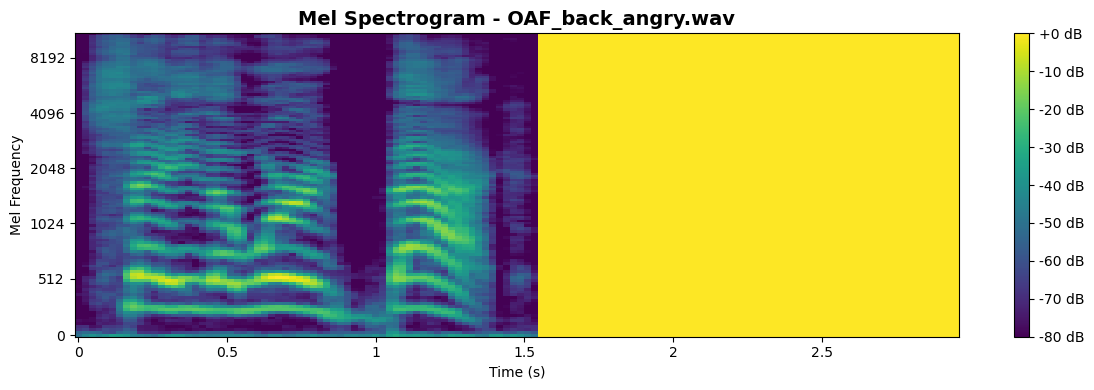

In [38]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_spec, sr=22050, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel Spectrogram - {os.path.basename(sample_file)}', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Mel Frequency')
plt.tight_layout()
plt.show()

In [40]:
print("Extracting spectrograms for all audio files")
spectrograms = []
labels_list = []
texts_list = []
failed_files = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    mel_spec = extract_mel_spectrogram(row['file_path'])
    
    if mel_spec is not None:
        spectrograms.append(mel_spec)
        labels_list.append(row['emotion'])
        texts_list.append(row['word'])
    else:
        failed_files.append(row['file_path'])

print(f"\n Spectrogram extraction complete!")
print(f"  Successfully processed: {len(spectrograms)} files")
print(f"  Failed: {len(failed_files)} files")

X_spectrograms = np.array(spectrograms)  # Shape: (N, n_mels, time_steps)
y_spec_labels = np.array(labels_list)

print(f"\nSpectrogram dataset shape: {X_spectrograms.shape}")
print(f"  Format: (num_samples, n_mels, time_steps)")

Extracting spectrograms for all audio files


Processing: 100%|██████████████████████████████████████████████████████████████████| 5600/5600 [01:40<00:00, 55.98it/s]



 Spectrogram extraction complete!
  Successfully processed: 5600 files
  Failed: 0 files

Spectrogram dataset shape: (5600, 128, 128)
  Format: (num_samples, n_mels, time_steps)


In [42]:
np.save('results/X_spectrograms.npy', X_spectrograms)
np.save('results/y_spec_labels.npy', y_spec_labels)
print("Spectrograms saved")

Spectrograms saved


In [44]:
y_spec_encoded = label_encoder.transform(y_spec_labels)

X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_spectrograms, y_spec_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_spec_encoded
)

print("Data Split:")
print(f"  Training: {X_train_spec.shape}")
print(f"  Testing: {X_test_spec.shape}")

X_train_spec = X_train_spec[:, np.newaxis, :, :]  
X_test_spec = X_test_spec[:, np.newaxis, :, :]

print(f"\nAfter adding channel dimension:")
print(f"  Training: {X_train_spec.shape}")
print(f"  Testing: {X_test_spec.shape}")

Data Split:
  Training: (4480, 128, 128)
  Testing: (1120, 128, 128)

After adding channel dimension:
  Training: (4480, 1, 128, 128)
  Testing: (1120, 1, 128, 128)


In [45]:
class EmotionDataset(Dataset):
    
    def __init__(self, spectrograms, labels):
        self.spectrograms = torch.FloatTensor(spectrograms)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.spectrograms[idx], self.labels[idx]


train_dataset = EmotionDataset(X_train_spec, y_train_spec)
test_dataset = EmotionDataset(X_test_spec, y_test_spec)

print(f" PyTorch datasets created!")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Testing samples: {len(test_dataset)}")

sample_spec, sample_label = train_dataset[0]
print(f"\nSample data:")
print(f"  Spectrogram shape: {sample_spec.shape}")
print(f"  Label: {sample_label} ({label_encoder.classes_[sample_label]})")

 PyTorch datasets created!
  Training samples: 4480
  Testing samples: 1120

Sample data:
  Spectrogram shape: torch.Size([1, 128, 128])
  Label: 1 (disgust)


In [64]:
# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0  
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

print(f" Data loaders created!")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Testing batches: {len(test_loader)}")

for batch_specs, batch_labels in train_loader:
    print(f"\nSample batch:")
    print(f"  Spectrograms shape: {batch_specs.shape}")
    print(f"  Labels shape: {batch_labels.shape}")
    break

 Data loaders created!
  Batch size: 32
  Training batches: 140
  Testing batches: 35

Sample batch:
  Spectrograms shape: torch.Size([32, 1, 128, 128])
  Labels shape: torch.Size([32])


   #### Convolutional Neural Network for Speech Emotion Recognition
   #### Input: Mel spectrogram (1, 128, 128)
   #### Output: Emotion class probabilities

In [73]:
class EmotionCNN(nn.Module):
    
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2) 
        self.dropout1 = nn.Dropout2d(0.25)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) 
        self.dropout2 = nn.Dropout2d(0.25)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  
        self.dropout3 = nn.Dropout2d(0.25)
        
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.dropout4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout5 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout4(x)
        x = F.relu(self.fc2(x))
        x = self.dropout5(x)
        x = self.fc3(x)
        
        return x


num_classes = len(label_encoder.classes_)
model_cnn = EmotionCNN(num_classes=num_classes).to(device)

print("CNN Model created!")
print(f"\nModel Architecture:")
print(model_cnn)

total_params = sum(p.numel() for p in model_cnn.parameters())
trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

CNN Model created!

Model Architecture:
EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout2d(p=0.25, inplace=False)
  (fc1): Linear(in_features=32768, out_features=25

In [75]:
def train_model(model, train_loader, test_loader, criterion, optimizer, 
                num_epochs=50, device=device):

    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    
    best_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for spectrograms, labels in train_bar:
            spectrograms, labels = spectrograms.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(spectrograms)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100*correct/total:.2f}%'
            })
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for spectrograms, labels in test_loader:
                spectrograms, labels = spectrograms.to(device), labels.to(device)
                
                outputs = model(spectrograms)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_loss = running_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = model.state_dict().copy()
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
        print(f'  Best Test Acc: {best_acc:.2f}%')
        print('-' * 60)
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'best_acc': best_acc
    }


print(" Training function defined")

 Training function defined


In [77]:
print("TRAINING CNN MODEL FOR SPEECH EMOTION RECOGNITION")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

NUM_EPOCHS = 10  

history_cnn = train_model(
    model_cnn, 
    train_loader, 
    test_loader, 
    criterion, 
    optimizer, 
    num_epochs=NUM_EPOCHS,
    device=device
)

print("CNN TRAINING COMPLETED!")
print(f"Best Test Accuracy: {history_cnn['best_acc']:.2f}%")

TRAINING CNN MODEL FOR SPEECH EMOTION RECOGNITION


Epoch 1/10 [Train]: 100%|███████████████████████████████████| 140/140 [01:52<00:00,  1.25it/s, loss=1.2480, acc=31.03%]


Epoch 1/10:
  Train Loss: 1.9420, Train Acc: 31.03%
  Test Loss: 1.1012, Test Acc: 58.39%
  Best Test Acc: 58.39%
------------------------------------------------------------


Epoch 2/10 [Train]: 100%|███████████████████████████████████| 140/140 [02:01<00:00,  1.15it/s, loss=1.1717, acc=47.68%]


Epoch 2/10:
  Train Loss: 1.2743, Train Acc: 47.68%
  Test Loss: 0.6562, Test Acc: 73.66%
  Best Test Acc: 73.66%
------------------------------------------------------------


...

Epoch 8/10:
  Train Loss: 0.4519, Train Acc: 81.36%
  Test Loss: 0.0911, Test Acc: 97.95%
  Best Test Acc: 97.95%
------------------------------------------------------------


Epoch 9/10 [Train]: 100%|███████████████████████████████████| 140/140 [02:20<00:00,  1.00s/it, loss=0.3036, acc=83.66%]


Epoch 9/10:
  Train Loss: 0.3997, Train Acc: 83.66%
  Test Loss: 0.0442, Test Acc: 99.73%
  Best Test Acc: 99.73%
------------------------------------------------------------


Epoch 10/10 [Train]: 100%|██████████████████████████████████| 140/140 [02:09<00:00,  1.08it/s, loss=0.2738, acc=84.53%]


Epoch 10/10:
  Train Loss: 0.3877, Train Acc: 84.53%
  Test Loss: 0.0563, Test Acc: 99.20%
  Best Test Acc: 99.73%
------------------------------------------------------------
CNN TRAINING COMPLETED!
Best Test Accuracy: 99.73%


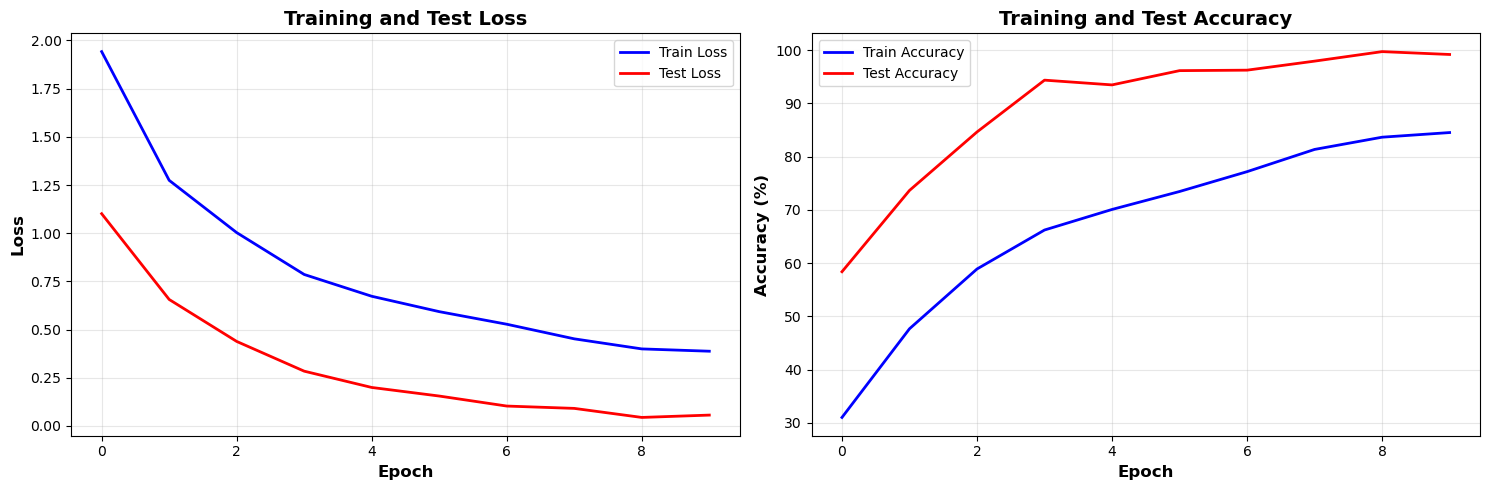

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_cnn['train_losses'], label='Train Loss', color='blue', linewidth=2)
axes[0].plot(history_cnn['test_losses'], label='Test Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training and Test Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn['train_accs'], label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(history_cnn['test_accs'], label='Test Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
def evaluate_model(model, test_loader, device=device):
    """
    Evaluate model and return predictions
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for spectrograms, labels in tqdm(test_loader, desc='Evaluating'):
            spectrograms = spectrograms.to(device)
            outputs = model(spectrograms)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)


y_pred_cnn, y_true_cnn = evaluate_model(model_cnn, test_loader)

cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn) * 100

print("CNN MODEL EVALUATION")
print(f"\nTest Accuracy: {cnn_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true_cnn, y_pred_cnn, 
                          target_names=label_encoder.classes_, 
                          digits=3))

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 35/35 [00:09<00:00,  3.82it/s]

CNN MODEL EVALUATION

Test Accuracy: 99.20%

Classification Report:
              precision    recall  f1-score   support

       angry      1.000     1.000     1.000       160
     disgust      0.988     1.000     0.994       160
        fear      1.000     0.994     0.997       160
       happy      1.000     0.963     0.981       160
     neutral      0.994     1.000     0.997       160
          ps      0.963     0.988     0.975       160
         sad      1.000     1.000     1.000       160

    accuracy                          0.992      1120
   macro avg      0.992     0.992     0.992      1120
weighted avg      0.992     0.992     0.992      1120



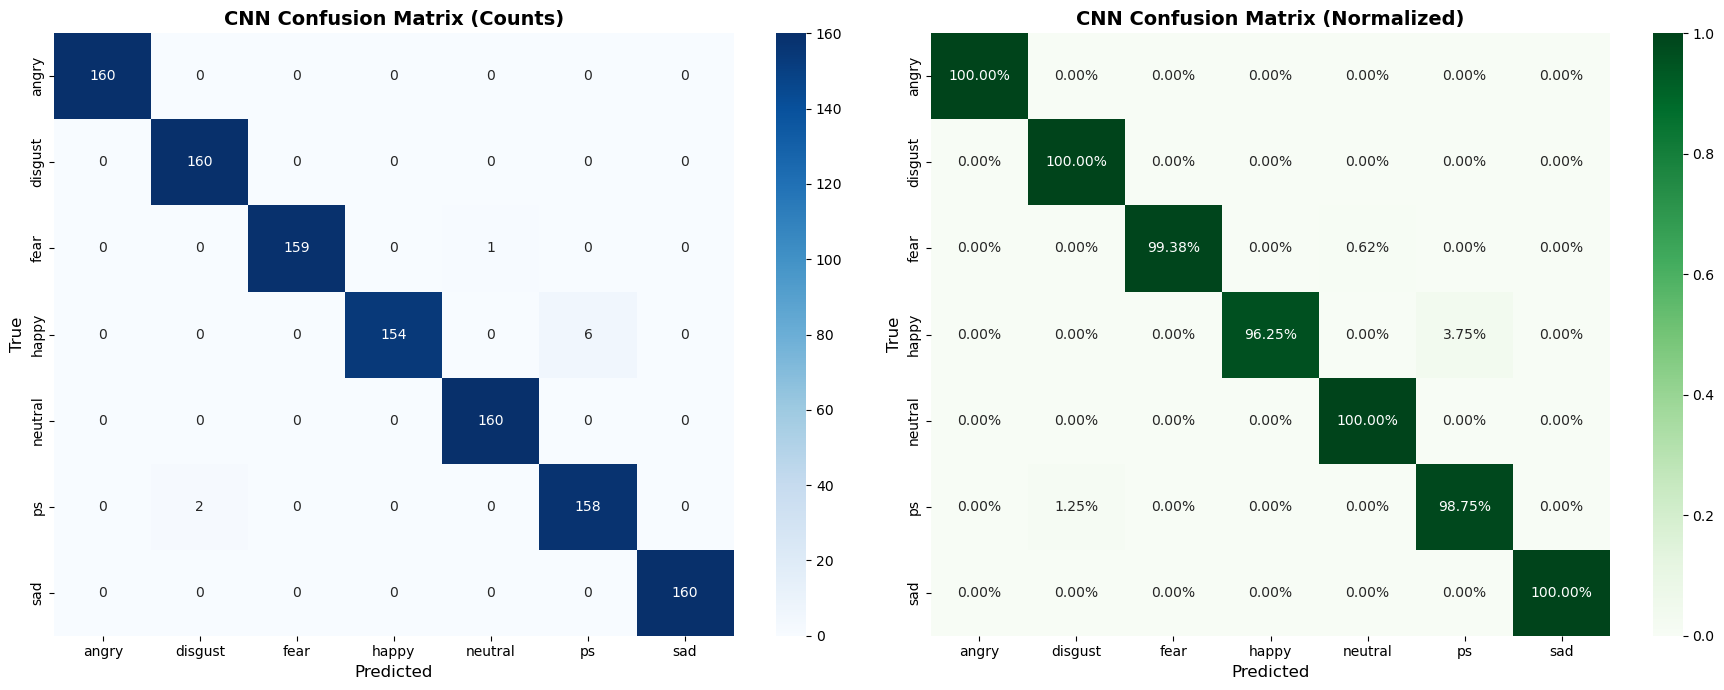

In [107]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0])
axes[0].set_title('CNN Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)

cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_cnn_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1])
axes[1].set_title('CNN Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)

plt.tight_layout()
plt.show()



# LSTM Model for Speech

In [112]:
class EmotionLSTM(nn.Module):
    
    def __init__(self, input_size=128, hidden_size=256, num_layers=2, num_classes=7):
        super(EmotionLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        
        self.fc1 = nn.Linear(hidden_size * 2, 128)  
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):

        x = x.squeeze(1)  
        x = x.permute(0, 2, 1)  # (batch, time_steps, n_mels)
        
        lstm_out, (hidden, cell) = self.lstm(x)
        

        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_combined = torch.cat([hidden_forward, hidden_backward], dim=1)
        
        x = F.relu(self.fc1(hidden_combined))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


model_lstm = EmotionLSTM(
    input_size=128, 
    hidden_size=256,
    num_layers=2,
    num_classes=num_classes
).to(device)

print("LSTM Model created!")
print(f"\nModel Architecture:")
print(model_lstm)

total_params = sum(p.numel() for p in model_lstm.parameters())
trainable_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

LSTM Model created!

Model Architecture:
EmotionLSTM(
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)

Total parameters: 2,434,055
Trainable parameters: 2,434,055


In [114]:
print("="*70)
print("TRAINING LSTM MODEL FOR SPEECH EMOTION RECOGNITION")
print("="*70)

criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)

NUM_EPOCHS_LSTM = 5

history_lstm = train_model(
    model_lstm,
    train_loader,
    test_loader,
    criterion_lstm,
    optimizer_lstm,
    num_epochs=NUM_EPOCHS_LSTM,
    device=device
)
print(f"Best Test Accuracy: {history_lstm['best_acc']:.2f}%")

TRAINING LSTM MODEL FOR SPEECH EMOTION RECOGNITION


Epoch 1/5 [Train]: 100%|████████████████████████████████████| 140/140 [01:07<00:00,  2.07it/s, loss=1.2466, acc=30.92%]


Epoch 1/5:
  Train Loss: 1.5519, Train Acc: 30.92%
  Test Loss: 1.2847, Test Acc: 40.62%
  Best Test Acc: 40.62%
------------------------------------------------------------


Epoch 2/5 [Train]: 100%|████████████████████████████████████| 140/140 [01:07<00:00,  2.08it/s, loss=1.3173, acc=37.10%]


Epoch 2/5:
  Train Loss: 1.3676, Train Acc: 37.10%
  Test Loss: 1.2729, Test Acc: 40.71%
  Best Test Acc: 40.71%
------------------------------------------------------------


...

Epoch 3/5:
  Train Loss: 1.3221, Train Acc: 38.82%
  Test Loss: 1.2581, Test Acc: 41.25%
  Best Test Acc: 41.25%
------------------------------------------------------------


Epoch 4/5 [Train]: 100%|████████████████████████████████████| 140/140 [01:05<00:00,  2.14it/s, loss=1.2908, acc=38.53%]


Epoch 4/5:
  Train Loss: 1.3181, Train Acc: 38.53%
  Test Loss: 1.2619, Test Acc: 40.98%
  Best Test Acc: 41.25%
------------------------------------------------------------


Epoch 5/5 [Train]: 100%|████████████████████████████████████| 140/140 [01:06<00:00,  2.12it/s, loss=1.2657, acc=38.62%]


Epoch 5/5:
  Train Loss: 1.3055, Train Acc: 38.62%
  Test Loss: 1.2544, Test Acc: 40.71%
  Best Test Acc: 41.25%
------------------------------------------------------------
Best Test Accuracy: 41.25%


In [116]:
y_pred_lstm, y_true_lstm = evaluate_model(model_lstm, test_loader)

lstm_accuracy = accuracy_score(y_true_lstm, y_pred_lstm) * 100

print("LSTM MODEL EVALUATION")
print(f"\nTest Accuracy: {lstm_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true_lstm, y_pred_lstm,
                          target_names=label_encoder.classes_,
                          digits=3))

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 35/35 [00:04<00:00,  8.17it/s]

LSTM MODEL EVALUATION

Test Accuracy: 40.71%

Classification Report:
              precision    recall  f1-score   support

       angry      0.000     0.000     0.000       160
     disgust      0.476     0.812     0.600       160
        fear      0.575     0.769     0.658       160
       happy      0.340     0.675     0.452       160
     neutral      0.324     0.456     0.379       160
          ps      0.000     0.000     0.000       160
         sad      0.244     0.138     0.176       160

    accuracy                          0.407      1120
   macro avg      0.280     0.407     0.324      1120
weighted avg      0.280     0.407     0.324      1120




C:\Users\vivek\anaconda3\envs\pytorch-env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vivek\anaconda3\envs\pytorch-env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vivek\anaconda3\envs\pytorch-env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

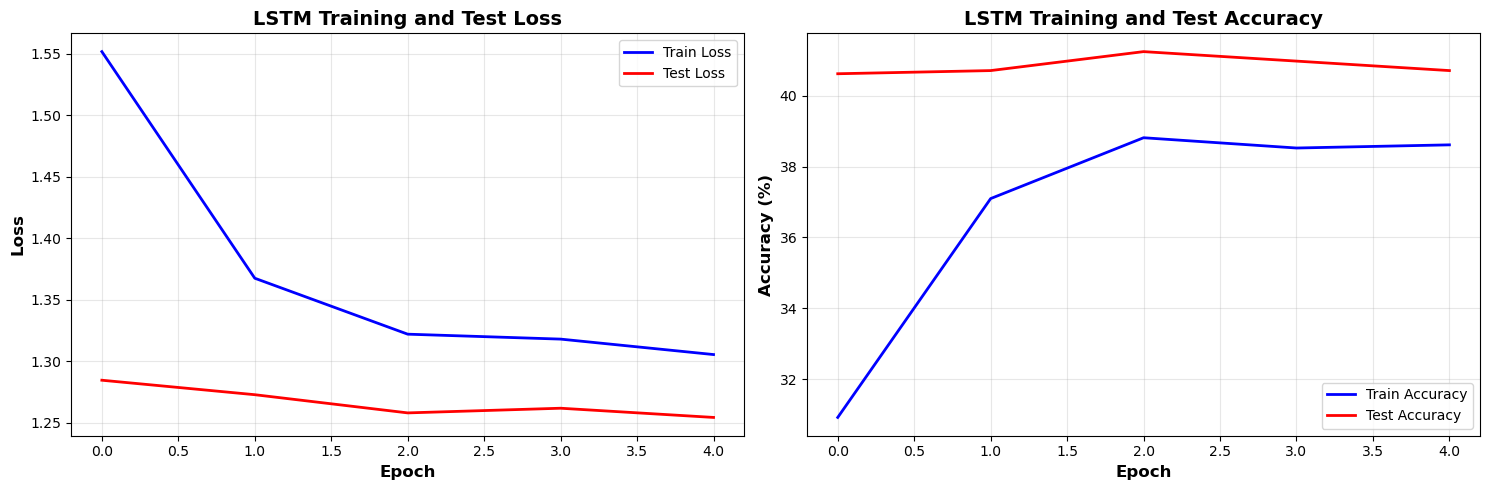

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_lstm['train_losses'], label='Train Loss', color='blue', linewidth=2)
axes[0].plot(history_lstm['test_losses'], label='Test Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('LSTM Training and Test Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm['train_accs'], label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(history_lstm['test_accs'], label='Test Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('LSTM Training and Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1000)
vectorizer.fit(texts_list)

vocab_size = len(vectorizer.vocabulary_) + 1  # +1 for padding
print(f"Vocabulary size: {vocab_size}")

def text_to_sequence(text, vectorizer, max_len=20):
    words = text.lower().split()
    vocab = vectorizer.vocabulary_
    sequence = [vocab.get(word, 0) for word in words]
    
    if len(sequence) < max_len:
        sequence = sequence + [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    
    return sequence

text_sequences = []
for text in texts_list:
    seq = text_to_sequence(text, vectorizer)
    text_sequences.append(seq)

X_text_seq = np.array(text_sequences)
print(f"Text sequences shape: {X_text_seq.shape}")

_, _, text_train_seq, text_test_seq = train_test_split(
    X_spectrograms, X_text_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_spec_encoded
)

print(f"Text training shape: {text_train_seq.shape}")
print(f"Text testing shape: {text_test_seq.shape}")

Vocabulary size: 201
Text sequences shape: (5600, 20)
Text training shape: (4480, 20)
Text testing shape: (1120, 20)


In [123]:
class TextEmotionLSTM(nn.Module):
    
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=128, num_classes=7):
        super(TextEmotionLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        hidden_combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        
        x = F.relu(self.fc1(hidden_combined))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


model_text = TextEmotionLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=128,
    num_classes=num_classes
).to(device)

print(" Text LSTM Model created!")
print(model_text)

total_params = sum(p.numel() for p in model_text.parameters())
print(f"\nTotal parameters: {total_params:,}")

 Text LSTM Model created!
TextEmotionLSTM(
  (embedding): Embedding(201, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
)

Total parameters: 702,087


In [125]:
class TextEmotionDataset(Dataset):
    
    def __init__(self, text_sequences, labels):
        self.text_sequences = torch.LongTensor(text_sequences)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.text_sequences[idx], self.labels[idx]


text_train_dataset = TextEmotionDataset(text_train_seq, y_train_spec)
text_test_dataset = TextEmotionDataset(text_test_seq, y_test_spec)

text_train_loader = DataLoader(text_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
text_test_loader = DataLoader(text_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f" Text data loaders created!")
print(f"  Training batches: {len(text_train_loader)}")
print(f"  Testing batches: {len(text_test_loader)}")

 Text data loaders created!
  Training batches: 140
  Testing batches: 35


In [127]:
print("TRAINING TEXT LSTM MODEL")

criterion_text = nn.CrossEntropyLoss()
optimizer_text = optim.Adam(model_text.parameters(), lr=0.001)

history_text = train_model(
    model_text,
    text_train_loader,
    text_test_loader,
    criterion_text,
    optimizer_text,
    num_epochs=30,
    device=device
)

print("TEXT LSTM TRAINING COMPLETED!")
print(f"Best Test Accuracy: {history_text['best_acc']:.2f}%")

TRAINING TEXT LSTM MODEL


Epoch 1/30 [Train]: 100%|███████████████████████████████████| 140/140 [00:06<00:00, 22.43it/s, loss=1.9440, acc=14.49%]


Epoch 1/30:
  Train Loss: 1.9488, Train Acc: 14.49%
  Test Loss: 1.9478, Test Acc: 14.29%
  Best Test Acc: 14.29%
------------------------------------------------------------


Epoch 2/30 [Train]: 100%|███████████████████████████████████| 140/140 [00:05<00:00, 23.53it/s, loss=1.9511, acc=14.29%]


Epoch 2/30:
  Train Loss: 1.9474, Train Acc: 14.29%
  Test Loss: 1.9492, Test Acc: 11.34%
  Best Test Acc: 14.29%
------------------------------------------------------------


...

Epoch 28/30:
  Train Loss: 1.9374, Train Acc: 16.36%
  Test Loss: 2.0636, Test Acc: 2.14%
  Best Test Acc: 14.29%
------------------------------------------------------------


Epoch 29/30 [Train]: 100%|██████████████████████████████████| 140/140 [00:06<00:00, 22.82it/s, loss=1.9481, acc=16.83%]


Epoch 29/30:
  Train Loss: 1.9362, Train Acc: 16.83%
  Test Loss: 2.0739, Test Acc: 2.32%
  Best Test Acc: 14.29%
------------------------------------------------------------


Epoch 30/30 [Train]: 100%|██████████████████████████████████| 140/140 [00:06<00:00, 23.03it/s, loss=1.9455, acc=15.58%]


Epoch 30/30:
  Train Loss: 1.9369, Train Acc: 15.58%
  Test Loss: 2.0657, Test Acc: 2.32%
  Best Test Acc: 14.29%
------------------------------------------------------------
TEXT LSTM TRAINING COMPLETED!
Best Test Accuracy: 14.29%


In [131]:
y_pred_text_dl, y_true_text_dl = evaluate_model(model_text, text_test_loader)

text_dl_accuracy = accuracy_score(y_true_text_dl, y_pred_text_dl) * 100

print("TEXT LSTM EVALUATION")
print(f"\nTest Accuracy: {text_dl_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true_text_dl, y_pred_text_dl,
                          target_names=label_encoder.classes_,
                          digits=3))

Evaluating: 100%|█████████████████████████████████████████████████████████████████████| 35/35 [00:00<00:00, 102.50it/s]

TEXT LSTM EVALUATION

Test Accuracy: 2.32%

Classification Report:
              precision    recall  f1-score   support

       angry      0.037     0.037     0.037       160
     disgust      0.018     0.025     0.021       160
        fear      0.039     0.031     0.035       160
       happy      0.015     0.013     0.013       160
     neutral      0.016     0.013     0.014       160
          ps      0.012     0.013     0.012       160
         sad      0.028     0.031     0.030       160

    accuracy                          0.023      1120
   macro avg      0.024     0.023     0.023      1120
weighted avg      0.024     0.023     0.023      1120



# Fusion Deep Learning Model

  """
    Multimodal Fusion Model
    Combines CNN (for speech) and Text LSTM
    """

In [137]:
class FusionModel(nn.Module):
  
    
    def __init__(self, num_classes=7, vocab_size=1000):
        super(FusionModel, self).__init__()
        
        self.speech_conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.speech_bn1 = nn.BatchNorm2d(32)
        self.speech_pool1 = nn.MaxPool2d(2, 2)
        
        self.speech_conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.speech_bn2 = nn.BatchNorm2d(64)
        self.speech_pool2 = nn.MaxPool2d(2, 2)
        
        self.speech_conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.speech_bn3 = nn.BatchNorm2d(128)
        self.speech_pool3 = nn.MaxPool2d(2, 2)
        
        self.speech_fc = nn.Linear(128 * 16 * 16, 256)
        
        self.text_embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.text_lstm = nn.LSTM(128, 128, num_layers=2, batch_first=True, 
                                 dropout=0.3, bidirectional=True)
        self.text_fc = nn.Linear(128 * 2, 128)
        
        self.fusion_fc1 = nn.Linear(256 + 128, 256)  
        self.dropout = nn.Dropout(0.5)
        self.fusion_fc2 = nn.Linear(256, 128)
        self.fusion_fc3 = nn.Linear(128, num_classes)
    
    def forward(self, speech, text):
        x_speech = F.relu(self.speech_bn1(self.speech_conv1(speech)))
        x_speech = self.speech_pool1(x_speech)
        
        x_speech = F.relu(self.speech_bn2(self.speech_conv2(x_speech)))
        x_speech = self.speech_pool2(x_speech)
        
        x_speech = F.relu(self.speech_bn3(self.speech_conv3(x_speech)))
        x_speech = self.speech_pool3(x_speech)
        
        x_speech = x_speech.view(x_speech.size(0), -1)
        x_speech = F.relu(self.speech_fc(x_speech))
        
        x_text = self.text_embedding(text)
        lstm_out, (hidden, _) = self.text_lstm(x_text)
        x_text = torch.cat([hidden[-2], hidden[-1]], dim=1)
        x_text = F.relu(self.text_fc(x_text))
        
        x_fused = torch.cat([x_speech, x_text], dim=1)
        x = F.relu(self.fusion_fc1(x_fused))
        x = self.dropout(x)
        x = F.relu(self.fusion_fc2(x))
        x = self.dropout(x)
        x = self.fusion_fc3(x)
        
        return x


model_fusion = FusionModel(num_classes=num_classes, vocab_size=vocab_size).to(device)

print("Fusion Model created!")
print(model_fusion)

total_params = sum(p.numel() for p in model_fusion.parameters())
print(f"\nTotal parameters: {total_params:,}")

Fusion Model created!
FusionModel(
  (speech_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (speech_bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (speech_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (speech_conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (speech_bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (speech_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (speech_conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (speech_bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (speech_pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (speech_fc): Linear(in_features=32768, out_features=256, bias=True)
  (text_embedding): Embedding(201, 128, padding_idx=0)
  (text_lstm): LSTM(

In [139]:
class FusionDataset(Dataset):
    
    def __init__(self, spectrograms, text_sequences, labels):
        self.spectrograms = torch.FloatTensor(spectrograms)
        self.text_sequences = torch.LongTensor(text_sequences)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.spectrograms[idx], self.text_sequences[idx], self.labels[idx]


fusion_train_dataset = FusionDataset(X_train_spec, text_train_seq, y_train_spec)
fusion_test_dataset = FusionDataset(X_test_spec, text_test_seq, y_test_spec)

fusion_train_loader = DataLoader(fusion_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
fusion_test_loader = DataLoader(fusion_test_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [141]:
def train_fusion_model(model, train_loader, test_loader, criterion, optimizer,
                       num_epochs=50, device=device):
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    best_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for speech, text, labels in train_bar:
            speech, text, labels = speech.to(device), text.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(speech, text)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            train_bar.set_postfix({'loss': f'{loss.item():.4f}', 
                                  'acc': f'{100*correct/total:.2f}%'})
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Testing
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for speech, text, labels in test_loader:
                speech, text, labels = speech.to(device), text.to(device), labels.to(device)
                outputs = model(speech, text)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_loss = running_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = model.state_dict().copy()
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
        print(f'  Best Test Acc: {best_acc:.2f}%')
        print('-' * 60)
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'best_acc': best_acc
    }

In [ ]:
print("TRAINING FUSION (MULTIMODAL) MODEL")

criterion_fusion = nn.CrossEntropyLoss()
optimizer_fusion = optim.Adam(model_fusion.parameters(), lr=0.001)

history_fusion = train_fusion_model(
    model_fusion,
    fusion_train_loader,
    fusion_test_loader,
    criterion_fusion,
    optimizer_fusion,
    num_epochs=5,
    device=device
)

print("FUSION MODEL TRAINING COMPLETED!")
print(f"Best Test Accuracy: {history_fusion['best_acc']:.2f}%")